# Sentiment Analysis on IMDb Movie Reviews - Multinomial Naive Bayes with TF-IDF

**Student Name:** `Kristina Asner 212692255, May Ashkenazi 212656631`

**Prompts** `[XXXX]`


**Problem.** We address **binary sentiment classification**: given the free text of a movie review, predict whether
the reviewer's overall sentiment is **positive** (`label = 1`) or **negative** (`label = 0`). This is a canonical
supervised NLP task and a standard benchmark for evaluating text classifiers here we use the **IMDb Movie Reviews**
dataset, provided as two pre split CSV files, `Train.csv` (model fitting) and `Test.csv` (held out evaluation). We do
**not** re split these files; `Test.csv` is treated as strictly unseen data until the final evaluation in Part 5.

### Naive Bayes: 

**Naive Bayes** is a **generative classifier** that models how each class creates data, rather than just drawing a decision boundary between them.

* **How it works:** It learns the prior probability of each class $P(y)$ and the likelihood of observing features given that class $P(x \mid y)$, then uses **Bayes' Rule** to predict the most probable class for new data:
  $$P(y \mid x) \propto P(x \mid y) \, P(y)$$
* **The "Naive" assumption:** It assumes all features are conditionally independent given the class, simplifying the joint probability calculation:
  $$P(x \mid y) = \prod_{i} P(x_i \mid y)$$
* **The trade off:** This strong assumption makes the model exceptionally fast and effective with small datasets, but introduces high bias when features are strongly correlated in reality.

**Multinomial Naive Bayes** is the classic generative model for text: each document is treated as a "bag of words"
drawn from a class specific multinomial distribution over the vocabulary, and the **naive** (conditional
independence) assumption lets us estimate that distribution efficiently from very high-dimensional, sparse text data.
The theoretical machinery behind this the independence assumption, the zero frequency problem, smoothing, and
log space computation is developed in Part 3, immediately before we implement it.

**Dataset structure.** Each CSV has two columns:

| column  | type | description                                            |
|---------|------|----------------------------------------------------------|
| `text`  | str  | raw, unprocessed review text (may contain HTML, e.g. `<br />`) |
| `label` | int  | `0` = negative sentiment, `1` = positive sentiment       |


In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_colwidth", 120)

# The raw CSVs are UTF-8 with a BOM on the header line -> utf-8-sig strips it cleanly.
train_df = pd.read_csv("Train.csv", encoding="utf-8-sig")
test_df = pd.read_csv("Test.csv", encoding="utf-8-sig")

print(f"Train.csv : {train_df.shape[0]:,} rows x {train_df.shape[1]} cols")
print(f"Test.csv  : {test_df.shape[0]:,} rows x {test_df.shape[1]} cols")

print("\n--- Train.csv (first 5 rows) ---")
display(train_df.head())

print("\n--- Test.csv (first 5 rows) ---")
display(test_df.head())

def class_balance(df, name):
    counts = df["label"].value_counts().sort_index()
    pct = (counts / len(df) * 100).round(2)
    print(f"\nClass distribution — {name}")
    for lbl in counts.index:
        tag = "negative" if lbl == 0 else "positive"
        print(f"  label={lbl} ({tag:8s}): {counts[lbl]:>6,} reviews  ({pct[lbl]}%)")

class_balance(train_df, "Train.csv")
class_balance(test_df, "Test.csv")


Train.csv : 40,000 rows x 2 cols
Test.csv  : 5,000 rows x 2 cols

--- Train.csv (first 5 rows) ---


,text,label
0,"I grew up (b. 1965) watching and loving the Thunderbirds. All my mates at school watched. We played ""Thunderbirds"" b...",0
1,"When I put this movie in my DVD player, and sat down with a coke and some chips, I had some expectations. I was hopi...",0
2,Why do people who do not know what a particular time in the past was like feel the need to try to define that time f...,0
3,"Even though I have great interest in Biblical movies, I was bored to death every minute of the movie. Everything is ...",0
4,"Im a die hard Dads Army fan and nothing will ever change that. I got all the tapes, DVD's and audiobooks and every t...",1



--- Test.csv (first 5 rows) ---


,text,label
0,"I always wrote this series off as being a complete stink-fest because Jim Belushi was involved in it, and heavily. B...",0
1,1st watched 12/7/2002 - 3 out of 10(Dir-Steve Purcell): Typical Mary Kate & Ashley fare with a few more kisses. It l...,0
2,This movie was so poorly written and directed I fell asleep 30 minutes through the movie. The jokes in the movie are...,0
3,"The most interesting thing about Miryang (Secret Sunshine) is the actors. Jeon Do-yeon, as Lee Shin-ae, the main cha...",1
4,"when i first read about ""berlin am meer"" i didn't expect much. but i thought with the right people, the right locati...",0



Class distribution — Train.csv
  label=0 (negative): 20,019 reviews  (50.05%)
  label=1 (positive): 19,981 reviews  (49.95%)

Class distribution — Test.csv
  label=0 (negative):  2,495 reviews  (49.9%)
  label=1 (positive):  2,505 reviews  (50.1%)


## Part 2 - Text Preprocessing & Feature Engineering (TF-IDF)

### 2.1 Preprocessing steps: Noise Removal → Tokenization → Normalization

Raw review text is noisy relative to the "clean" signal we actually want the model to learn from. We apply three
preprocessing stages, in order:

1. **Noise removal.** IMDb reviews were scraped from HTML pages, so they still contain markup artifacts (most
   commonly `<br />` line breaks). These carry no sentiment information and must be stripped, along with punctuation
   and non alphabetic clutter, before anything else - otherwise a token like `"great<br"` would be treated as a
   distinct, unseen word from `"great"`, artificially inflating the vocabulary and fragmenting useful signal.
2. **Tokenization.** The cleaned string is split into discrete word tokens. `TfidfVectorizer`'s default tokenizer
   uses a regex (`\b\w\w+\b`) that extracts alphanumeric tokens of length ≥ 2, which conveniently also drops stray
   single characters and punctuation left over from stage 1.
3. **Normalization.** We apply **case folding** (lowercasing) so that `"Great"`, `"GREAT"`, and `"great"` all map to
   a single vocabulary entry, and we remove **stopwords** (`the`, `is`, `a`, ...) - extremely high-frequency function
   words that carry syntactic rather than sentiment information and would otherwise dominate raw counts.

### 2.2 Zipf's Law and why TF-IDF beats raw term frequency

**Zipf's Law** observes that in natural language corpora, word frequency is inversely proportional to its frequency
rank:

$$ \text{freq}(w) \propto \frac{1}{\text{rank}(w)} $$

A small number of words (stopwords, common verbs) account for a hugely disproportionate share of total word
occurrences, while the vast majority of vocabulary words appear rarely. This has two consequences for feature
design:

- **Dimensionality reduction is essential.** The long Zipfian tail means the raw vocabulary is enormous, but most of
  it is uninformative for classification (either too rare to generalize from, or too common to discriminate between
  classes). We control this with `max_features` (a hard vocabulary cap keeping only the most frequent terms) and
  `stop_words='english'` (dropping the head of the Zipf curve entirely).
- **Raw counts overweight frequent-but-uninformative words.** A term that appears in *every* document (near the head
  of the Zipf curve) contributes little discriminative signal, yet under raw term frequency it would dominate a
  document's representation simply by sheer count. **TF-IDF** (Term Frequency × Inverse Document Frequency) corrects
  for this:

$$ \text{tfidf}(t, d) = \text{tf}(t, d) \times \text{idf}(t), \qquad
   \text{idf}(t) = \ln\!\left(\frac{1 + N}{1 + \text{df}(t)}\right) + 1 $$

where $N$ is the number of documents in the corpus and $\text{df}(t)$ is the number of documents containing term
$t$. The IDF factor **penalizes corpus common words** (large $\text{df}(t)$ → small IDF) and **amplifies rare,
informative terms** (small $\text{df}(t)$ → large IDF). This is precisely the correction Zipf's Law tells us we
need, and it is why TF-IDF weighting rather than raw counts is the standard feature representation for text
classification.

We additionally use **bigrams** (`ngram_range=(1, 2)`) alongside unigrams, since single words lose local word order
information that matters for sentiment (e.g. `"not good"` vs. `"good"` are opposite in meaning but share the unigram
`"good"`; the bigram `"not_good"` recovers the distinction).

In [2]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer

HTML_TAG_RE = re.compile(r"<[^>]+>")
NON_ALPHA_RE = re.compile(r"[^a-zA-Z\s]")
MULTI_SPACE_RE = re.compile(r"\s+")

def clean_text(raw_text: str) -> str:
    '''Noise removal + case folding. Tokenization/stopword handling is delegated to TfidfVectorizer.'''
    text = HTML_TAG_RE.sub(" ", raw_text)          # strip HTML tags, e.g. <br />
    text = NON_ALPHA_RE.sub(" ", text)              # drop digits/punctuation noise
    text = text.lower()                             # case folding
    text = MULTI_SPACE_RE.sub(" ", text).strip()    # collapse whitespace
    return text

train_df["clean_text"] = train_df["text"].astype(str).map(clean_text)
test_df["clean_text"] = test_df["text"].astype(str).map(clean_text)

# --- TF-IDF vectorization: unigrams + bigrams, English stopwords removed, fit on Train only ---
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    stop_words="english",
    max_features=30_000,
    min_df=5,
    sublinear_tf=True,
)

X_train_tfidf = vectorizer.fit_transform(train_df["clean_text"])   # fit + transform on Train
X_test_tfidf = vectorizer.transform(test_df["clean_text"])         # transform ONLY on Test (no leakage)

feature_names = vectorizer.get_feature_names_out()
print(f"Vocabulary size (max_features cap): {len(feature_names):,}")
print(f"Train TF-IDF matrix: {X_train_tfidf.shape}  (sparsity: {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1]):.4%})")
print(f"Test  TF-IDF matrix: {X_test_tfidf.shape}")


def show_tfidf_example(raw_text, clean, tfidf_row, feature_names, top_k=10):
    '''Pretty-print a raw snippet next to its cleaned tokens and top-weighted TF-IDF features.'''
    print("RAW SNIPPET   :", raw_text[:180].replace("\n", " ") + "...")
    tokens = clean.split()
    print("TOKENS (first 15):", tokens[:15])
    row = tfidf_row.tocoo()
    pairs = sorted(zip(row.col, row.data), key=lambda p: -p[1])[:top_k]
    print(f"TOP {top_k} TF-IDF FEATURES:")
    for col, weight in pairs:
        print(f"    {feature_names[col]:<20s} {weight:.4f}")
    print("-" * 80)

print("\n=== Example 1 (Train, index 0) ===")
show_tfidf_example(train_df["text"].iloc[0], train_df["clean_text"].iloc[0], X_train_tfidf[0], feature_names)

print("\n=== Example 2 (Train, index 1) ===")
show_tfidf_example(train_df["text"].iloc[1], train_df["clean_text"].iloc[1], X_train_tfidf[1], feature_names)

print("\n=== Example 3 (Test, index 0) ===")
show_tfidf_example(test_df["text"].iloc[0], test_df["clean_text"].iloc[0], X_test_tfidf[0], feature_names)


Vocabulary size (max_features cap): 30,000
Train TF-IDF matrix: (40000, 30000)  (sparsity: 99.6751%)
Test  TF-IDF matrix: (5000, 30000)

=== Example 1 (Train, index 0) ===
RAW SNIPPET   : I grew up (b. 1965) watching and loving the Thunderbirds. All my mates at school watched. We played "Thunderbirds" before school, during lunch and after school. We all wanted to be...
TOKENS (first 15): ['i', 'grew', 'up', 'b', 'watching', 'and', 'loving', 'the', 'thunderbirds', 'all', 'my', 'mates', 'at', 'school', 'watched']
TOP 10 TF-IDF FEATURES:
    thunderbirds         0.3400
    virgil               0.1710
    utter rubbish        0.1689
    school               0.1619
    gerry                0.1613
    movie hoping         0.1606
    grew watching        0.1575
    homo                 0.1569
    bitterly             0.1564
    art form             0.1500
--------------------------------------------------------------------------------

=== Example 2 (Train, index 1) ===
RAW SNIPPET   : When I

## Part 3 - Model Implementation & Mathematical Foundations

### 1. Generative Decision Rule & Naive Independence
Naive Bayes classifies a document $x = (x_1, \dots, x_n)$ by applying Bayes' Rule and assuming features are conditionally independent given the class $y$:

$$P(y \mid x) \propto P(y) \prod_{i=1}^{n} P(x_i \mid y)$$

* **Prior $P(y)$:** Class proportions in the training set.
* **Likelihood $P(x_i \mid y)$:** Word frequency given the class, reducing parameter complexity from $O(2^n)$ to $O(n)$.

---

### 2. Zero Frequency Problem & Additive Smoothing
If a test word never appeared in class $y$ during training, standard MLE yields $P(x_i \mid y) = 0$, zeroing out the entire product. 

We apply additive smoothing ($\alpha$) to ensure non zero probabilities across vocabulary $V$:

$$\hat{P}(x_i \mid y) = \frac{\text{count}(x_i, y) + \alpha}{\sum_{j} \text{count}(x_j, y) + \alpha |V|}$$

* $\alpha = 1.0$: Laplace smoothing (default).
* $0 < \alpha < 1$: Lidstone smoothing (lighter correction for large vocabularies).

---

### 3. Log Space Computation (Numerical Stability)
Multiplying hundreds of small probabilities causes floating-point **underflow**. Transforming the decision rule into log space replaces products with stable sums:

$$\hat{y} = \arg\max_{y} \left[ \log P(y) + \sum_{i=1}^{n} x_i \log P(x_i \mid y) \right]$$

---

### 4. Implementation & Smoke Test
Below, we wrap `MultinomialNB` into modular helper functions for fitting and inference, extracting both discrete predictions and numerically stable log posteriors (`predict_log_proba`), followed by a quick smoke test on a small slice of data.

In [ ]:
from sklearn.naive_bayes import MultinomialNB


#train a Multinomial Naive Bayes model on the TF-IDF vectors and labels
def train_model(X_train_vec, y_train, alpha=1.0):
    model = MultinomialNB(alpha=alpha)
    model.fit(X_train_vec, y_train)
    return model


#predict labels and log-posteriors for the given TF-IDF vectors using the trained model
def predict_model(model, X_vec):    
    y_pred = model.predict(X_vec)
    y_log_proba = model.predict_log_proba(X_vec)   # log-space posterior
    return y_pred, y_log_proba



_smoke_model = train_model(X_train_tfidf[:2000], train_df["label"].iloc[:2000], alpha=1.0)
_pred, _logp = predict_model(_smoke_model, X_test_tfidf[:5])
print("Smoke-test predictions:", _pred)
print("Smoke-test log-posteriors (class 0, class 1):\n", np.round(_logp, 3))


Smoke-test predictions: [0 0 0 0 0]
Smoke-test log-posteriors (class 0, class 1):
 [[-0.357 -1.203]
 [-0.417 -1.076]
 [-0.136 -2.063]
 [-0.612 -0.781]
 [-0.203 -1.694]]


## Part 4 - Hyperparameter Tuning: Smoothing Parameter ($\alpha$)

In the following cell, we evaluate different smoothing strategies for the **Multinomial Naive Bayes** classifier using the precomputed TF-IDF training matrix:

* **Evaluated Configurations:** We sweep across three key regimes of $\alpha$:
  * $\alpha \approx 0$ (`1e-9`): Approximates pure **MLE** without smoothing.
  * $\alpha = 1.0$: Classic **Laplace** smoothing.
  * $\alpha = 0.1$: **Lidstone** smoothing for a lighter correction on large vocabularies.
* **Validation Strategy:** Each setting is evaluated using **3 fold Stratified Cross Validation** on the training data, tracking both the mean and standard deviation of the **F1 score** alongside execution time.
* **Selection:** The configuration yielding the highest mean F1 score is identified, displayed in a summary table, and stored for final model training.

In [4]:
import time
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Training data is already vectorized once in Part 2 (X_train_tfidf) -- we reuse that
# precomputed feature matrix directly and only sweep the smoothing hyperparameter, alpha.
y_train = train_df["label"]

alpha_configs = [
    {"name": "alpha\u22480 (MLE)",        "alpha": 1e-9},
    {"name": "alpha=1.0 (Laplace)",  "alpha": 1.0},
    {"name": "alpha=0.1 (Lidstone)", "alpha": 0.1},
]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
results = []

for cfg in alpha_configs:
    model = MultinomialNB(alpha=cfg["alpha"])
    t0 = time.time()
    f1_scores = cross_val_score(model, X_train_tfidf, y_train, cv=cv, scoring="f1", n_jobs=-1)
    elapsed = time.time() - t0

    results.append({
        "name": cfg["name"],
        "alpha": cfg["alpha"],
        "mean_f1": f1_scores.mean(),
        "std_f1": f1_scores.std(),
        "seconds": elapsed,
    })
    print(f"{cfg['name']:<22s} | mean F1 = {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f}) | {elapsed:.1f}s")

results_df = pd.DataFrame(results).sort_values("mean_f1", ascending=False).reset_index(drop=True)
print("\n=== Hyperparameter comparison (sorted by mean CV F1) ===")
display(results_df)

best_cfg = results_df.iloc[0]
BEST_ALPHA = float(best_cfg["alpha"])
print(f"\nSelected configuration: {best_cfg['name']}  ->  alpha={BEST_ALPHA}")


alpha≈0 (MLE)          | mean F1 = 0.8676 (+/- 0.0026) | 1.8s


alpha=1.0 (Laplace)    | mean F1 = 0.8748 (+/- 0.0026) | 1.3s


alpha=0.1 (Lidstone)   | mean F1 = 0.8754 (+/- 0.0021) | 1.3s

=== Hyperparameter comparison (sorted by mean CV F1) ===


,name,alpha,mean_f1,std_f1,seconds
0,alpha=0.1 (Lidstone),1.000000e-01,0.875403,0.002119,1.344573
1,alpha=1.0 (Laplace),1.000000e+00,0.874794,0.002570,1.346802
2,alpha≈0 (MLE),1.000000e-09,0.867555,0.002553,1.801504



Selected configuration: alpha=0.1 (Lidstone)  ->  alpha=0.1


## Part 5 - Model Inference & Comprehensive Evaluation

In this final stage, we train the classifier on the entire training set using the optimal hyperparameter found in Part 4 and evaluate its generalized performance on the untouched test set (`Test.csv`).

---

### 1. Evaluation Metrics & Mathematical Formulations

Taking `label = 1` (positive sentiment) as the positive class and `label = 0` as the negative class:

* **Precision :** The proportion of positive predictions that were actually correct. Low precision indicates a high number of false alarms (False Positives).
  $$\text{Precision} = \frac{TP}{TP + FP}$$

* **Recall :** The proportion of actual positive cases that the model successfully captured. Low recall indicates many missed positive cases (False Negatives).
  $$\text{Recall} = \frac{TP}{TP + FN}$$

* **F1-Score :** Balances Precision and Recall into a single metric. The harmonic mean ensures that a model cannot achieve a high score by severely compromising one metric for the other:
  $$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

* **Confusion Matrix:** The full $2 \times 2$ contingency table mapping true labels against predicted labels to analyze error distribution ($FP$ vs. $FN$):

| | Predicted Negative ($0$) | Predicted Positive ($1$) |
|---|:---:|:---:|
| **True Negative ($0$)** | True Negative ($TN$) | False Positive ($FP$) |
| **True Positive ($1$)** | False Negative ($FN$) | True Positive ($TP$) |

---

### 2. Execution Flow in the Next Cell

1. **Train & Predict:** Fit `MultinomialNB(alpha=BEST_ALPHA)` on the full `X_train_tfidf` and run inference on `X_test_tfidf` to obtain both discrete predictions (`y_pred`) and log-posteriors (`y_log_proba`).
2. **Qualitative Inspection:** Display a side by side comparison table of the first 5 test samples showing true sentiment, predicted sentiment, and review snippets.
3. **Quantitative Evaluation:** Output the primary binary $F_1$-score on the positive class and print the full `classification_report` (Precision, Recall, F1 for both classes).
4. **Heatmap Visualization:** Plot the Seaborn confusion matrix heatmap to inspect misclassification patterns.

=== First 5 test predictions ===


,true_sentiment,predicted_sentiment,review_snippet
0,negative,negative,I always wrote this series off as being a complete stink-fest because Jim Belushi was involved in it...
1,negative,negative,1st watched 12/7/2002 - 3 out of 10(Dir-Steve Purcell): Typical Mary Kate & Ashley fare with a few m...
2,negative,negative,This movie was so poorly written and directed I fell asleep 30 minutes through the movie. The jokes ...
3,positive,positive,"The most interesting thing about Miryang (Secret Sunshine) is the actors. Jeon Do-yeon, as Lee Shin-..."
4,negative,negative,"when i first read about ""berlin am meer"" i didn't expect much. but i thought with the right people, ..."



*** Test-set F1-Score (positive class) = 0.8777 ***

=== Classification Report ===
              precision    recall  f1-score   support

negative (0)       0.88      0.87      0.88      2495
positive (1)       0.87      0.89      0.88      2505

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



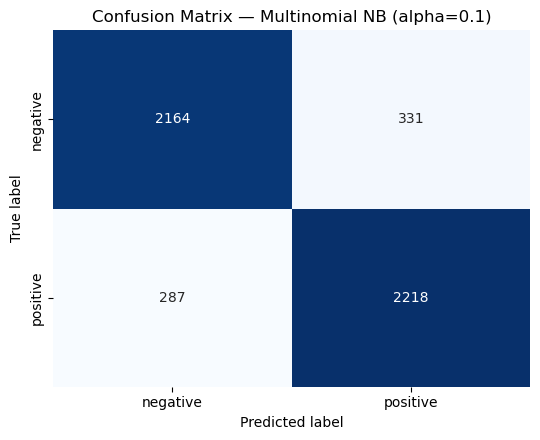

In [ ]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

final_model = train_model(X_train_tfidf, train_df["label"], alpha=BEST_ALPHA)

y_test = test_df["label"]
y_pred, y_log_proba = predict_model(final_model, X_test_tfidf)

# --- First 5 test predictions: true vs. predicted vs. review snippet ---
label_map = {0: "negative", 1: "positive"}
preview = pd.DataFrame({
    "true_sentiment": [label_map[v] for v in y_test.iloc[:5]],
    "predicted_sentiment": [label_map[v] for v in y_pred[:5]],
    "review_snippet": [t[:100] + "..." for t in test_df["text"].iloc[:5]],
})
print("=== First 5 test predictions ===")
display(preview)

# --- Primary metric: binary F1 on the positive class ---
test_f1 = f1_score(y_test, y_pred, pos_label=1)
print(f"\n*** Test-set F1-Score (positive class) = {test_f1:.4f} ***")

# --- Full classification report ---
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["negative (0)", "positive (1)"]))

# --- Confusion matrix heatmap ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["negative", "positive"], yticklabels=["negative", "positive"],
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix — Multinomial NB (alpha={BEST_ALPHA})")
plt.tight_layout()
plt.show()


## Conclusion

We built a sentiment classifier for IMDb movie reviews: we cleaned the review text, converted it to
**TF-IDF** features (unigrams + bigrams), and trained a **Multinomial Naive Bayes** model, tuning the
smoothing parameter to $\alpha = 0.1$ with cross-validation.

**End result:** on the 5,000 unseen test reviews the model achieved **~88% accuracy** and an
**F1-score of ~0.88** on the positive class, with errors balanced between the two classes.

**What the algorithm succeeded in doing:** from the review text alone, it correctly distinguishes
positive from negative reviews about 88% of the time a fast, simple, and interpretable model that
generalizes well (the test score matches the cross validation score, so it is not overfit).
